# Detector Setup
This notebook is to walks through the steps for operating detectors using `sodetlib` functions once you have your readout setup the 3 most general/basic steps are:
1. Use the `tickle` functions to generate a `bias_group` to `band`, `channel` mapping
2. Take and analyze IVs
3. Chose and set a bias point from your IV data.

### Standard Imports

In [1]:
from sodetlib.det_config import DetConfig
import sodetlib.smurf_funcs.smurf_ops as so
import sodetlib.smurf_funcs.optimize_params as op
import sodetlib.smurf_funcs.det_ops as do
import sodetlib.analysis.det_analysis as da
import sodetlib.util as su
from importlib import reload
from tqdm import tqdm
import numpy as np
import glob

import matplotlib.pyplot as plt
%matplotlib inline

from scipy.signal import welch

# Warnings are annoying
import warnings
warnings.filterwarnings("ignore")

### Get dev_cfg and pysmurf object
See setup notebook, same steps

In [2]:
cfg = DetConfig()
cfg.load_config_files(slot=2)
S = cfg.get_smurf_control(apply_dev_configs=False, make_logfile=True)

### 1. Running Tickle Functions
Calling this a `tickle` function name is a holdover from the SPT/PB nomenclature for a small sinusoidal signal added on top of your DC bias (or in SPT/PB AC bias). We basically put in a sine wave on the bias line whose bias power is much smaller than the mean bias power so it well approximated the small signal limit (or a local derivative) we then measure the amplitude of the sine wave once it goes through the SQUID and the ratio of the input amplitude to the measured amplitude tells you the resistance. We then play this tickle sequentially on each bias line and use this to generate a map of which band/channel pairs are on which bias line and what their resistance is at their current DC bias level (a cut is also made on amplitudes less than some threshold which we consider to be crosstalk).

**take_tickle**

Arguments:

- `S, cfg` - just passing pysmurf control and device config objects.
- `range(12)` - specifies to run on all bias groups (0 to 11)
- `tickle_freq` - sets the frequency that the tickle is run at (in Hz)
- `tickle_voltage` - The amplitude of the tickle in low current mode volts.
- `high_current=True` - This is set to true because in `low_current` mode there is a low pass filter in-line that cuts off at ~1Hz which you bypass in `high_current` mode


**analyze_tickle_data**

Arguments:

- `S` - just passing pysmurf control pbjects.
- `sfile` - Filepath to output file generated by `take_tickle` with info needed for analysis.
- `normal_thresh` - Threshold for map to call a channel normal or in transition in Ohms

In [3]:
#Currently analyze_tickle_data doesn't pull R_sh from device_config so as a work around we just set it here
#In the future PR it will pull from device config as well
S.R_sh = 0.0004

Setting bias_group 0 to high current mode.
Changing bias from 0.9999847412109375 to 0.49260332079356534 to preserve dc-current.
Playing sine wave on bias group 0
Restoring bg 0 to low-current mode  and dc bias to 0.9999847412109375
Setting bias_group 1 to high current mode.
Changing bias from 0.9999847412109375 to 0.49260332079356534 to preserve dc-current.
Playing sine wave on bias group 1
Restoring bg 1 to low-current mode  and dc bias to 0.9999847412109375
Setting bias_group 2 to high current mode.
Changing bias from 0.9999847412109375 to 0.49260332079356534 to preserve dc-current.
Playing sine wave on bias group 2
Restoring bg 2 to low-current mode  and dc bias to 0.9999847412109375
Playing sine wave on bias group 3
Setting bias_group 4 to high current mode.
Changing bias from 0.9999847412109375 to 0.49260332079356534 to preserve dc-current.
Playing sine wave on bias group 4
Restoring bg 4 to low-current mode  and dc bias to 0.9999847412109375
Setting bias_group 5 to high current m

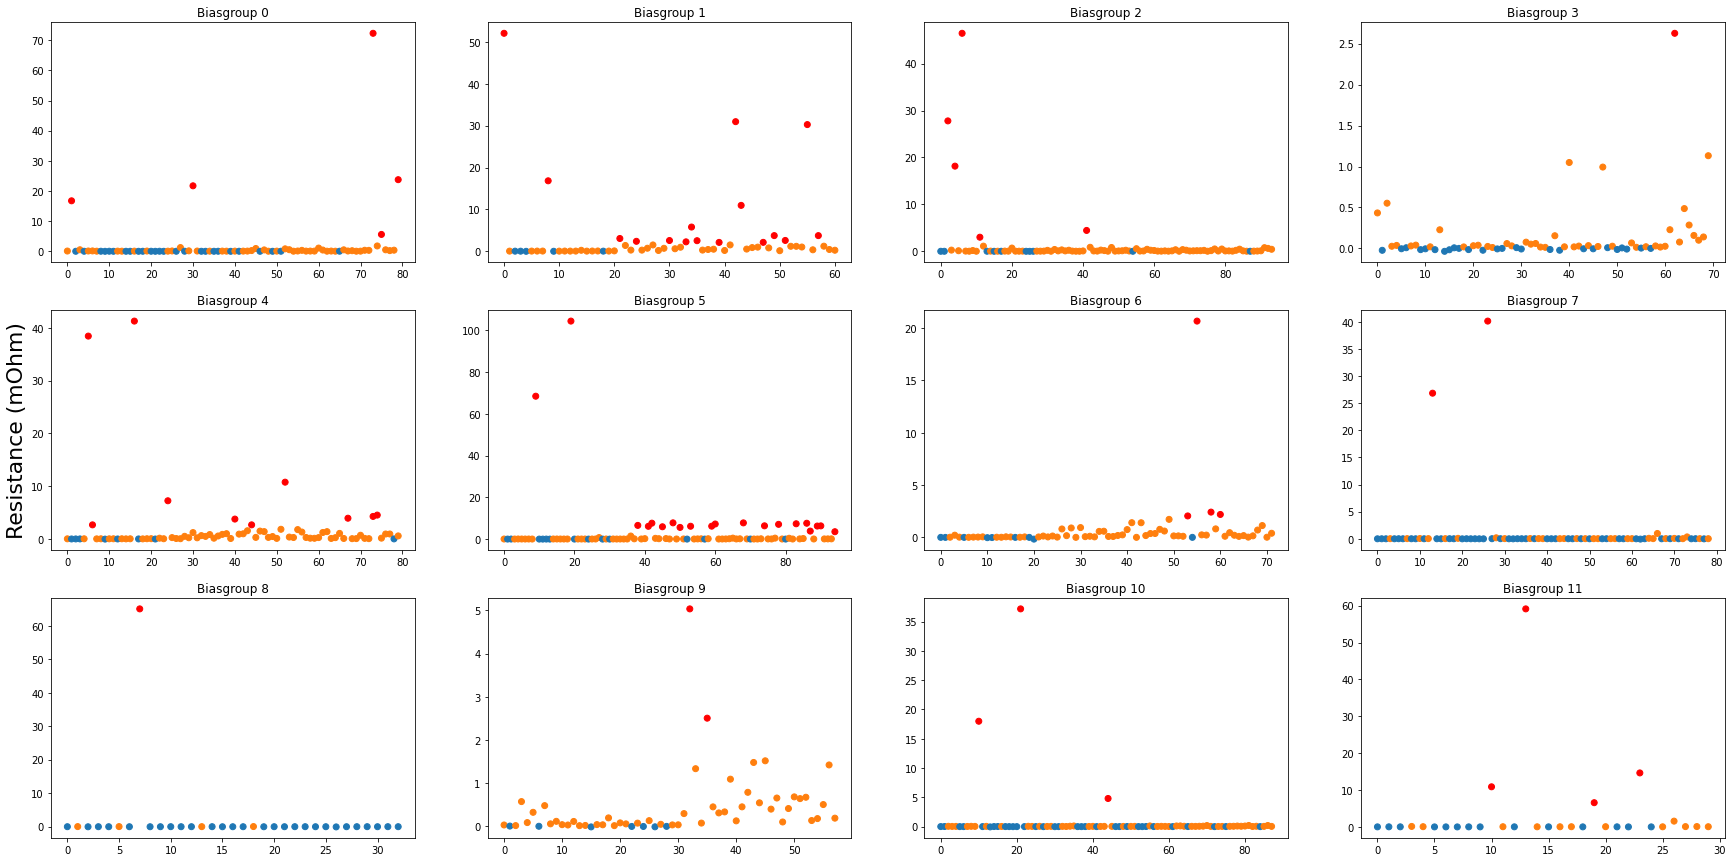

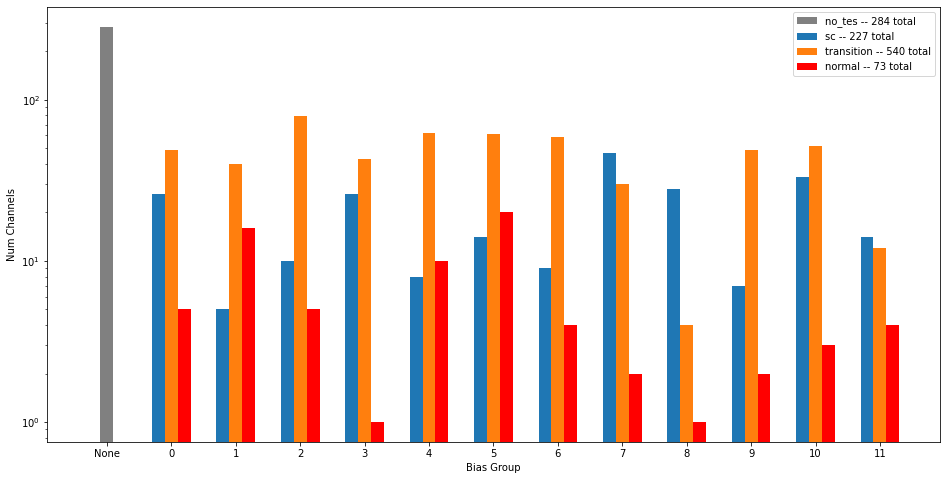

In [4]:
sfile = do.take_tickle(S, cfg, range(12), tickle_freq=5, tickle_voltage=0.005,high_current=True)
summary = da.analyze_tickle_data(S, sfile,normal_thresh=0.002)

The output of the tickle analysis is a dictionary with keys organized as:
- `R_sh` - Shunt resistance used to calculate channel resistances
- `run_summary` - Pertinent info on how data was taken and what filed were written during take_tickle
- `abs_channels` - 1D array of readout channels (smurf_band*512 + smurf_channel)
- `bg_assignments` - Bias group assignments (0-11 or none) same size as `abs_channels`
- `rsquared` - Fit quality to bias tickle sine wave.
- `current_mean` - Amplitude of measured tickle in current units same size as `abs_channels`
- `current_command` - Float of commanded tickle amplitude in current units
- `resistances` - calculated resistances same size as `abs_channels`
- `classifications` - Normal, superconducting, in transition, or no detector same size as `abs_channels`

See an example of the dictionary output below

In [5]:
print(f'Top Level Keys:\n{summary.keys()}')

Top Level Keys:
dict_keys(['R_sh', 'run_summary', 'abs_channels', 'bg_assignments', 'rsquared', 'current_meas', 'current_cmd', 'resistances', 'classifications'])


To generate the standardized bias group map format that can be used in other functions from this tickle output dictionary we can run the function `make_bias_group_map` and just pass it a pysmurf control object and this tickle analysis dictionary. 

Currently you need to search for the filepath to the tickle analysis to generate this bias group map in the future we will handle this better.

In [6]:
fps = [] 
ctimes = []
for fp in glob.glob(f'{S.output_dir}/*_tickle_analysis.npy*'):
    fps.append(fp)
    ctimes.append(int(fp.split('outputs/')[-1].split('_')[0]))
idx = np.argmin(np.asarray(ctimes))
analyzed_tick_fp = fps[idx]

In [7]:
bg_map_fp = da.make_bias_group_map(S,analyzed_tick_fp)

[ 2021-07-14 22:53:25 ]  Writing bias group mapping to /data/smurf_data/bias_group_maps/1626303201_bg_map.npy.


### Take and Analyze IVs


In [ ]:
bgs = np.arange(12)
S.load_tune(cfg.dev.exp['tunefile'])
iv_info = do.take_iv(S, cfg, bias_groups=bgs, bias_high=12.0, bias_step=0.1, cool_wait=30.,
                     wait_time = .1, high_current_mode=False, overbias_voltage=19.9, 
                     cool_voltage=12., bias_low = 1.0)

[ 2021-07-14 22:53:25 ]  filename explicitly given. Overriding last_tune bool in load_tune.
[ 2021-07-14 22:53:25 ]  Done loading tuning
[ 2021-07-14 22:53:25 ]  Loading tune data for all bands=[0, 1, 2, 3, 4, 5, 6, 7].
[ 2021-07-14 22:53:25 ]  Driving 19.9 V in high current mode through bias groups [ 0  1  2  3  4  5  6  7  8  9 10 11]. Waiting 2.0
[ 2021-07-14 22:53:27 ]  setting to low current
[ 2021-07-14 22:53:28 ]  Waiting 30.00 seconds to cool
[ 2021-07-14 22:53:58 ]  Done waiting.
[ 2021-07-14 22:53:58 ]  Starting to take IV.
[ 2021-07-14 22:53:58 ]  Starting TES bias ramp.
[ 2021-07-14 22:53:58 ]  Starting IV at 1626303238
[ 2021-07-14 22:53:58 ]  Input downsample factor is None. Using value already in pyrogue: 20
[ 2021-07-14 22:53:58 ]  Flux ramp is AC-coupled.
[ 2021-07-14 22:53:58 ]  caput smurf_server_s2:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2021-07-14 22:53:58 ]  caput smurf_server_s2:AMCc:SmurfProcessor:Filter:reset 1
[ 2021-07-14 22:53:58 ]  Writing to file : /data/s

In [ ]:
S._rtm_slow_dac_bit_to_volt

In [ ]:
timestamp, phase, mask, tes_biases = da.load_from_sid(cfg, iv_info)
iv_analyze = da.analyze_iv_and_save(S, cfg, iv_info, phase, tes_biases, mask)

In [ ]:
iv_info_dict = np.load(iv_info,allow_pickle=True).item()
iv_analyze_dict = np.load(iv_analyze,allow_pickle=True).item()
da.iv_summary_plots(iv_info_dict, iv_analyze_dict, show_plot=True)

In [ ]:
chans_to_plot = np.fromiter(iv_analyze_dict['data'][0].keys(),dtype = 'float')[:10]
da.iv_channel_plots(iv_info_dict, iv_analyze_dict, bands=[0], chans=chans_to_plot,
                     plot_dir=None, show_plot=True, save_plot=True)

### Find and set bias point

In [ ]:
biases_fp = da.bias_points_from_rfrac(S, iv_analyze, bg_map_fp)

In [ ]:
do.bias_detectors_from_sc(S, biases_fp)

In [ ]:
sid = so.take_g3_data(S, 30, make_freq_mask=False, tag='noise')
am = so.load_session(cfg, sid)
fig, axes = so.plot_band_noise(am, nbins=50)